In [106]:
# Imports
import sys
sys.path.insert(0, "..") 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from catboost import CatBoostClassifier

from src.constants import (
    TARGET_COL,
    MULTILABEL_COLS,
    CATEGORICAL_COLS,
    CLASS_LABELS,
    RANDOM_STATE,
    CV_SPLITS,
    PROCESSED_DATA_PATH,
    ARTIFACTS_PATH
)

from src.preprocessing import load_processed_dataset, temporal_train_val_test_split

from src.encoders import (
    fit_mlb_encoder,
    fit_ohe_encoder,
    build_mlb_cat_matrix,
    build_mlb_ohe_matrix,
    save_encoders
)

from src.evaluation import (
    evaluate_classification_model,
    fit_catboost_classifier,
    compare_results_table
)

from src.visualisations import (
    plot_calibration_curve,
    plot_feature_importance,
    get_original_feature
)

In [107]:
# Load preprocessed dataset
df = load_processed_dataset(PROCESSED_DATA_PATH)
df.info()

# Apply and verify the temporal train/test split
df_train, df_val, df_test = temporal_train_val_test_split(df)
print(f"\nTraining rows: {len(df_train)}")
print(f"Validation rows: {len(df_val)}")
print(f"Testing rows: {len(df_test)}")
print(f"\nTraining timeframe:\n {df_train[["year", "quarter"]].drop_duplicates().sort_values(['year', 'quarter']).to_string(index=False)}")
print(f"\nValidation timeframe:\n {df_val[["year", "quarter"]].drop_duplicates().sort_values(['year', 'quarter']).to_string(index=False)}")
print(f"\nTesting timeframe:\n {df_test[["year", "quarter"]].drop_duplicates().sort_values(['year', 'quarter']).to_string(index=False)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9250 entries, 0 to 9249
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   year                       9250 non-null   int64 
 1   quarter                    9250 non-null   object
 2   data_subject_type          9250 non-null   object
 3   data_type                  9250 non-null   object
 4   decision_taken             9250 non-null   object
 5   incident_category          9250 non-null   object
 6   incident_type              9250 non-null   object
 7   no_data_subjects_affected  9250 non-null   object
 8   time_taken_to_report       9250 non-null   object
dtypes: int64(1), object(8)
memory usage: 650.5+ KB

Training rows: 6165
Validation rows: 1147
Testing rows: 1938

Training timeframe:
  year quarter
 2021   Qtr 2
 2021   Qtr 3
 2021   Qtr 4
 2022   Qtr 1
 2022   Qtr 2
 2022   Qtr 3
 2022   Qtr 4
 2023   Qtr 1
 2023   Qtr 2
 2023   Qtr 3

In [108]:
print(df_train[TARGET_COL].value_counts(normalize=True))
print(df_val[TARGET_COL].value_counts(normalize=True))
print(df_test[TARGET_COL].value_counts(normalize=True))

decision_taken
Informal Action Taken    0.797405
No Further Action        0.117599
Investigation Pursued    0.084996
Name: proportion, dtype: float64
decision_taken
Informal Action Taken    0.800349
No Further Action        0.161290
Investigation Pursued    0.038361
Name: proportion, dtype: float64
decision_taken
Informal Action Taken    0.947368
No Further Action        0.037152
Investigation Pursued    0.015480
Name: proportion, dtype: float64


In [109]:
# Fit encoders on the training set 
mlb_encoder = fit_mlb_encoder(df_train, MULTILABEL_COLS)
ohe_encoder = fit_ohe_encoder(df_train, CATEGORICAL_COLS)

# Verify the number of unique labels found for each multilabel column
for col, encoder in mlb_encoder.items():
    print(f"{col}: {len(encoder.classes_)} unique labels found")

data_subject_type: 16 unique labels found
data_type: 26 unique labels found


In [110]:
# Build mlb + categorical feature matrices for CatBoost native handling
X_train_cat, cat_feature_indices = build_mlb_cat_matrix(df_train, mlb_encoder)
X_val_cat, _ = build_mlb_cat_matrix(df_val, mlb_encoder)
X_test_cat, _ = build_mlb_cat_matrix(df_test, mlb_encoder)

y_train = df_train[TARGET_COL].reset_index(drop=True)
y_val = df_val[TARGET_COL].reset_index(drop=True)
y_test = df_test[TARGET_COL].reset_index(drop=True)

X_train_val_cat = pd.concat([X_train_cat, X_val_cat], axis=0).reset_index(drop=True)
y_train_val = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)


print(f"Categorical indicies: {cat_feature_indices}")
print(f"Categorical columns: {CATEGORICAL_COLS}")
print(f"X_train_cat shape: {X_train_cat.shape}")
print(f"X_test_cat shape: {X_test_cat.shape}")
print(f"\nHead of X_train_cat:\n {X_train_cat.head(3).to_string()}")

assert X_train_cat.isnull().sum().sum() == 0, "Null values found in X_train_cat"
assert X_test_cat.isnull().sum().sum() == 0, "Null values found in X_test_cat"
print("\nNo null values found in mlb + cat feature matrices.")


Categorical indicies: [0, 1, 2, 3]
Categorical columns: ['incident_category', 'incident_type', 'no_data_subjects_affected', 'time_taken_to_report']
X_train_cat shape: (6165, 46)
X_test_cat shape: (1938, 46)

Head of X_train_cat:
   incident_category                                              incident_type no_data_subjects_affected  time_taken_to_report  data_subject_type__ Customers or prospective customers  data_subject_type__ Employees  data_subject_type__ Patients  data_subject_type__ Students  data_subject_type__ Subscribers  data_subject_type__ Users  data_subject_type__ Vulnerable adults  data_subject_type__Children  data_subject_type__Customers or prospective customers  data_subject_type__Employees  data_subject_type__Patients  data_subject_type__Students  data_subject_type__Subscribers  data_subject_type__Unknown  data_subject_type__Users  data_subject_type__Vulnerable adults  data_type__ Criminal convictions or offences  data_type__ Data revealing racial or ethnic origin  da

In [111]:
# Train MLB + OHE CatBoost model
X_train_ohe = build_mlb_ohe_matrix(df_train, mlb_encoder, ohe_encoder)
X_val_ohe = build_mlb_ohe_matrix(df_val, mlb_encoder, ohe_encoder)
X_test_ohe = build_mlb_ohe_matrix(df_test, mlb_encoder, ohe_encoder)

print(f"X_train_ohe shape: {X_train_ohe.shape}")
print(f"X_val_ohe shape: {X_val_ohe.shape}")
print(f"X_test_ohe shape: {X_test_ohe.shape}")
print(f"\nHead of X_train_ohe:\n {X_train_ohe.head(3).to_string()}")

X_train_ohe shape: (6165, 76)
X_val_ohe shape: (1147, 76)
X_test_ohe shape: (1938, 76)

Head of X_train_ohe:
    incident_category_Cyber  incident_category_Non Cyber  incident_type_Alteration of personal data  incident_type_Brute Force  incident_type_Data emailed to incorrect recipient  incident_type_Data of wrong data subject shown in client portal  incident_type_Data posted or faxed to incorrect recipient  incident_type_Denial of service  incident_type_Failure to redact  incident_type_Failure to use bcc  incident_type_Hardware/software misconfiguration  incident_type_Incorrect disposal of hardware  incident_type_Incorrect disposal of paperwork  incident_type_Loss/theft of device containing personal data  incident_type_Loss/theft of paperwork or data left in insecure location  incident_type_Malware  incident_type_Not Provided  incident_type_Other cyber incident  incident_type_Other non-cyber incident  incident_type_Phishing  incident_type_Ransomware  incident_type_Unauthorised access 

Evaluating CatBoost No Weights Baseline (MLB + Categorical)


Classification Report:
                       precision    recall  f1-score   support

Informal Action Taken       0.96      0.94      0.95      1836
Investigation Pursued       0.00      0.00      0.00        30
    No Further Action       0.21      0.43      0.28        72

             accuracy                           0.91      1938
            macro avg       0.39      0.46      0.41      1938
         weighted avg       0.92      0.91      0.91      1938

Accuracy: 0.9066
Macro F1 Score: 0.4120
Macro Precision: 0.3918
Macro Recall: 0.4569
Macro ROC AUC: 0.7317
Macro PR AUC: 0.3949
Log Loss: 0.5819

Per-Class F1 Scores:
	Informal Action Taken: F1 Score: 0.9515, ROC AUC: 0.7568
	Investigation Pursued: F1 Score: 0.0000, ROC AUC: 0.6695
	No Further Action: F1 Score: 0.2844, ROC AUC: 0.7688


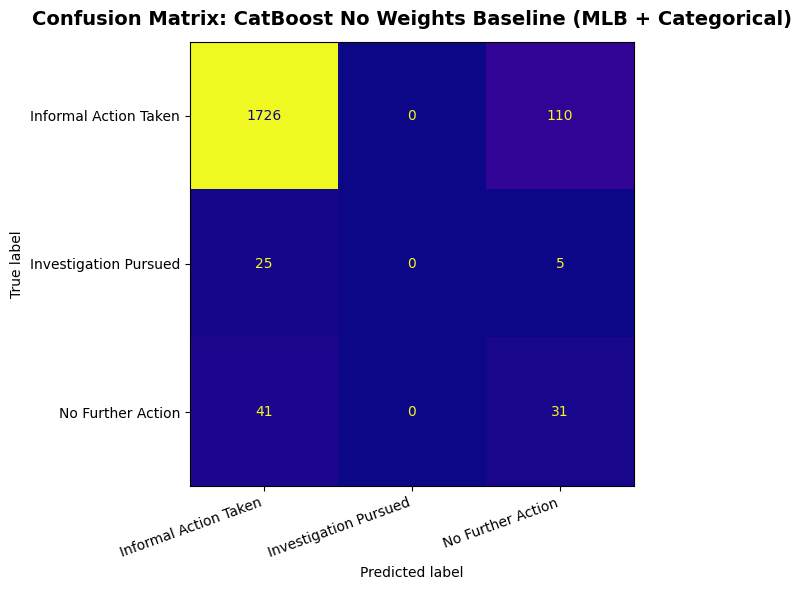

Confusion Matrix table:

                       Informal Action Taken  Investigation Pursued  \
Informal Action Taken                   1726                      0   
Investigation Pursued                     25                      0   
No Further Action                         41                      0   

                       No Further Action  
Informal Action Taken                110  
Investigation Pursued                  5  
No Further Action                     31  
Evaluating CatBoost Balanced Baseline (MLB + Categorical)


Classification Report:
                       precision    recall  f1-score   support

Informal Action Taken       0.97      0.76      0.85      1836
Investigation Pursued       0.02      0.23      0.04        30
    No Further Action       0.22      0.50      0.31        72

             accuracy                           0.74      1938
            macro avg       0.41      0.50      0.40      1938
         weighted avg       0.93      0.74      0.82   

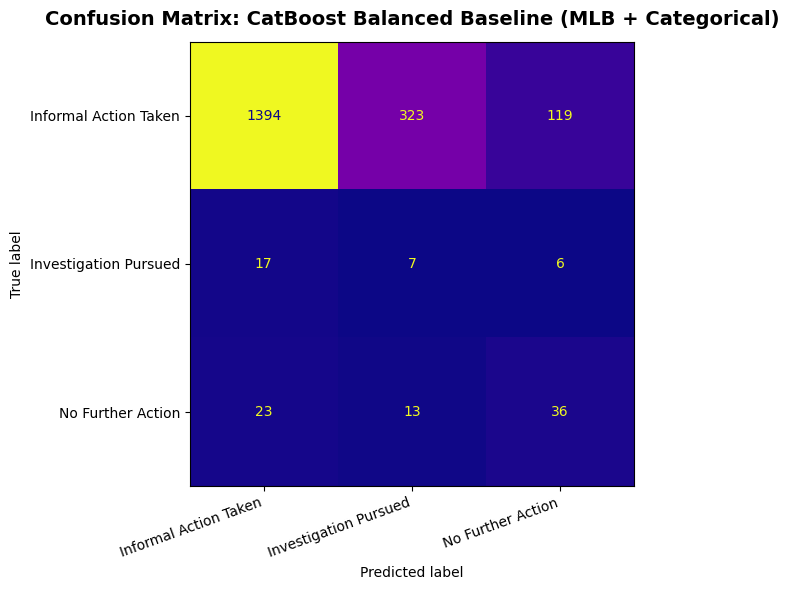

Confusion Matrix table:

                       Informal Action Taken  Investigation Pursued  \
Informal Action Taken                   1394                    323   
Investigation Pursued                     17                      7   
No Further Action                         23                     13   

                       No Further Action  
Informal Action Taken                119  
Investigation Pursued                  6  
No Further Action                     36  


In [112]:
mlb_cat_models = {}
mlb_cat_results = {}

mlb_cat_models["none"], mlb_cat_results["none"] = fit_catboost_classifier(
    "CatBoost No Weights Baseline (MLB + Categorical)",
    X_train_cat,
    y_train,
    X_test_cat,
    y_test,
    X_val_cat,
    y_val,
    cat_feature_indices=cat_feature_indices,
    class_weights=None,
)

mlb_cat_models["baseline"], mlb_cat_results["baseline"] = fit_catboost_classifier(
    "CatBoost Balanced Baseline (MLB + Categorical)",
    X_train_cat,
    y_train,
    X_test_cat,
    y_test,
    X_val_cat,
    y_val,
    cat_feature_indices=cat_feature_indices,
    class_weights="Balanced",
)

Evaluating CatBoost No Weights Baseline (MLB + OHE)


Classification Report:
                       precision    recall  f1-score   support

Informal Action Taken       0.96      0.97      0.97      1836
Investigation Pursued       0.00      0.00      0.00        30
    No Further Action       0.35      0.43      0.39        72

             accuracy                           0.94      1938
            macro avg       0.44      0.47      0.45      1938
         weighted avg       0.93      0.94      0.93      1938

Accuracy: 0.9365
Macro F1 Score: 0.4518
Macro Precision: 0.4389
Macro Recall: 0.4674
Macro ROC AUC: 0.7313
Macro PR AUC: 0.4216
Log Loss: 0.6809

Per-Class F1 Scores:
	Informal Action Taken: F1 Score: 0.9680, ROC AUC: 0.7613
	Investigation Pursued: F1 Score: 0.0000, ROC AUC: 0.6209
	No Further Action: F1 Score: 0.3875, ROC AUC: 0.8117


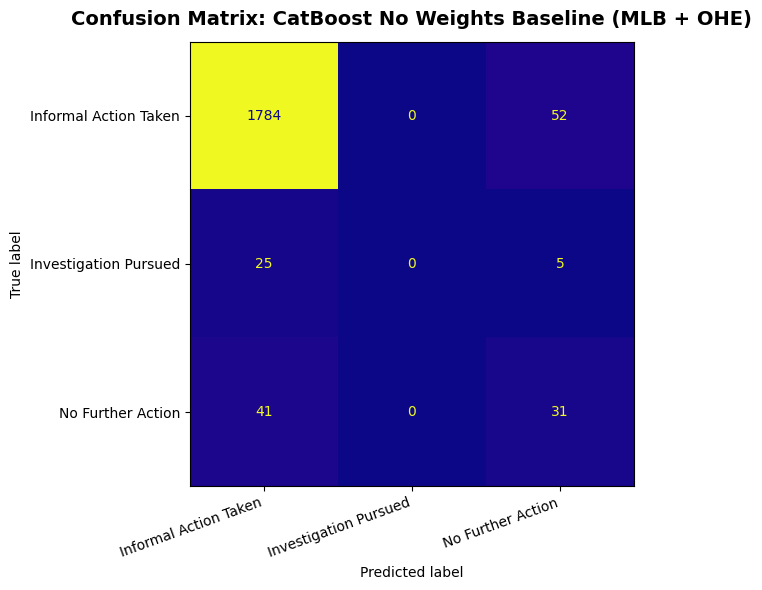

Confusion Matrix table:

                       Informal Action Taken  Investigation Pursued  \
Informal Action Taken                   1784                      0   
Investigation Pursued                     25                      0   
No Further Action                         41                      0   

                       No Further Action  
Informal Action Taken                 52  
Investigation Pursued                  5  
No Further Action                     31  
Evaluating CatBoost Balanced Baseline (MLB + OHE)


Classification Report:
                       precision    recall  f1-score   support

Informal Action Taken       0.96      0.81      0.88      1836
Investigation Pursued       0.00      0.03      0.01        30
    No Further Action       0.21      0.46      0.29        72

             accuracy                           0.78      1938
            macro avg       0.39      0.43      0.39      1938
         weighted avg       0.92      0.78      0.84      1938


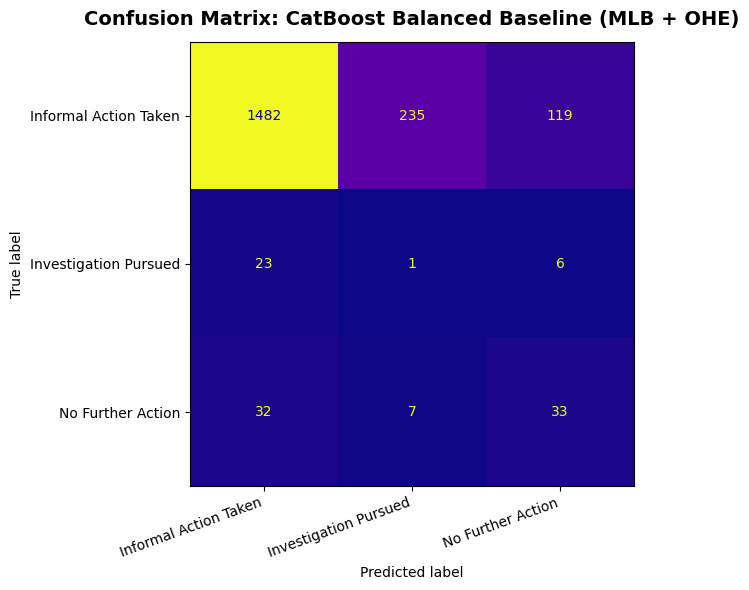

Confusion Matrix table:

                       Informal Action Taken  Investigation Pursued  \
Informal Action Taken                   1482                    235   
Investigation Pursued                     23                      1   
No Further Action                         32                      7   

                       No Further Action  
Informal Action Taken                119  
Investigation Pursued                  6  
No Further Action                     33  


In [113]:
mlb_ohe_models = {}
mlb_ohe_results = {}

mlb_ohe_models["none"], mlb_ohe_results["none"] = fit_catboost_classifier(
    "CatBoost No Weights Baseline (MLB + OHE)",
    X_train_ohe,
    y_train,
    X_test_ohe,
    y_test,
    X_val_ohe,
    y_val,
    cat_feature_indices=None,
    class_weights=None,
)

mlb_ohe_models["baseline"], mlb_ohe_results["baseline"] = fit_catboost_classifier(
    "CatBoost Balanced Baseline (MLB + OHE)",
    X_train_ohe,
    y_train,
    X_test_ohe,
    y_test,
    X_val_ohe,
    y_val,
    cat_feature_indices=None,
    class_weights="Balanced",
)

In [114]:
cb_encoding_comparison = compare_results_table(
    [mlb_cat_results["none"], mlb_cat_results["baseline"], mlb_ohe_results["none"], mlb_ohe_results["baseline"]],
    print_table=False
)
display(cb_encoding_comparison)

,model,accuracy,macro_f1,macro_precision,macro_recall,macro_roc_auc,macro_pr_auc,log_loss,f1_Informal Action Taken,roc_auc_Informal Action Taken,f1_Investigation Pursued,roc_auc_Investigation Pursued,f1_No Further Action,roc_auc_No Further Action
0,CatBoost No Weights Baseline (MLB + Categorical),0.906605,0.411964,0.391833,0.456881,0.731683,0.394871,0.581929,0.9515,0.7568,0.0000,0.6695,0.2844,0.7688
1,CatBoost Balanced Baseline (MLB + Categorical),0.741486,0.399715,0.405372,0.497531,0.746632,0.422482,0.809478,0.8526,0.7931,0.0375,0.6513,0.3090,0.7955
2,CatBoost No Weights Baseline (MLB + OHE),0.936533,0.451829,0.438866,0.467411,0.731297,0.421616,0.680927,0.9680,0.7613,0.0000,0.6209,0.3875,0.8117
3,CatBoost Balanced Baseline (MLB + OHE),0.782250,0.391008,0.392397,0.432952,0.655153,0.375249,1.086874,0.8787,0.7050,0.0073,0.5851,0.2870,0.6753


In [115]:
tscv = TimeSeriesSplit(n_splits=CV_SPLITS)
param_grid = {
    "learning_rate": [0.03, 0.05, 0.07, 0.1],
    "depth": [6, 8, 10, 12],
    "l2_leaf_reg": [1, 3, 5, 7]
}

In [116]:
bw_tuned_model = CatBoostClassifier(
    iterations=2000,
    loss_function="MultiClass",
    random_state=RANDOM_STATE,
    cat_features=cat_feature_indices,
    early_stopping_rounds=50,
    eval_metric="TotalF1:average=Macro",
    auto_class_weights="Balanced",
    verbose=False
)

bw_grid_result = bw_tuned_model.grid_search(
    param_grid,
    X=X_train_cat,
    y=y_train,
    cv=tscv,
    stratified=False,
    refit=False,
    shuffle=False,
    verbose=False
)

c:\Users\elsad\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:1262: UserWarning: The groups parameter is ignored by TimeSeriesSplit
  warnings.warn(


Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6954599994
bestIteration = 33

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7004098412
bestIteration = 62

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7059667784
bestIteration = 55

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7095276422
bestIteration = 36

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6987675981
bestIteration = 108

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.700803737
bestIteration = 52

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7002249425
bestIteration = 88

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6990274653
bestIteration = 125

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.701758617
bestIteration = 76

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7011978401
bestIteration = 100

Stopped b

In [117]:
nw_tuned_model = CatBoostClassifier(
    iterations=2000,
    loss_function="MultiClass",
    random_state=RANDOM_STATE,
    cat_features=cat_feature_indices,
    early_stopping_rounds=50,
    eval_metric="TotalF1:average=Macro",
    auto_class_weights="None",
    verbose=False
)

nw_grid_result = nw_tuned_model.grid_search(
    param_grid,
    X=X_train_cat,
    y=y_train,
    cv=tscv,
    stratified=False,
    refit=False,
    shuffle=False,
    verbose=False
)

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4530002633
bestIteration = 177

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4667491595
bestIteration = 175

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4661787352
bestIteration = 132

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4733436503
bestIteration = 163

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4416307926
bestIteration = 88

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4577862112
bestIteration = 156

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4586066076
bestIteration = 126

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4593690479
bestIteration = 178

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.439703154
bestIteration = 138

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4710963455
bestIteration = 361

St

In [118]:
print("\nBest parameters found:")
for key, value in bw_grid_result["params"].items():
    print(f"\t{key}: {value}")

bw_cv_curve = pd.DataFrame(bw_grid_result["cv_results"])
bw_best_iteration = bw_cv_curve["test-TotalF1:average=Macro-mean"].idxmax()
bw_train_f1 = bw_cv_curve.loc[bw_best_iteration, "train-TotalF1:average=Macro-mean"]
bw_test_f1  = bw_cv_curve.loc[bw_best_iteration, "test-TotalF1:average=Macro-mean"]
bw_test_std = bw_cv_curve.loc[bw_best_iteration, "test-TotalF1:average=Macro-std"]

print(f"\nCV diagnostics for best combination:")
print(f"\tBest iteration: {bw_best_iteration} of {len(bw_cv_curve)} total")
print(f"\tTrain F1: {bw_train_f1:.4f}")
print(f"\tTest F1: {bw_test_f1:.4f} (std across folds: {bw_test_std:.4f})")
print(f"\tTrain-test gap: {bw_train_f1 - bw_test_f1:.4f}")


Best parameters found:
	depth: 10
	learning_rate: 0.05
	l2_leaf_reg: 3

CV diagnostics for best combination:
	Best iteration: 34 of 119 total
	Train F1: 0.7224
	Test F1: 0.5390 (std across folds: 0.0916)
	Train-test gap: 0.1835


In [119]:
print("\nBest parameters found:")
for key, value in nw_grid_result["params"].items():
    print(f"\t{key}: {value}")

nw_cv_curve = pd.DataFrame(nw_grid_result["cv_results"])
nw_best_iteration = nw_cv_curve["test-TotalF1:average=Macro-mean"].idxmax()
nw_train_f1 = nw_cv_curve.loc[nw_best_iteration, "train-TotalF1:average=Macro-mean"]
nw_test_f1  = nw_cv_curve.loc[nw_best_iteration, "test-TotalF1:average=Macro-mean"]
nw_test_std = nw_cv_curve.loc[nw_best_iteration, "test-TotalF1:average=Macro-std"]

print(f"\nCV diagnostics for best combination:")
print(f"\tBest iteration: {nw_best_iteration} of {len(nw_cv_curve)} total")
print(f"\tTrain F1: {nw_train_f1:.4f}")
print(f"\tTest F1: {nw_test_f1:.4f} (std across folds: {nw_test_std:.4f})")
print(f"\tTrain-test gap: {nw_train_f1 - nw_test_f1:.4f}")


Best parameters found:
	depth: 12
	learning_rate: 0.1
	l2_leaf_reg: 1

CV diagnostics for best combination:
	Best iteration: 215 of 266 total
	Train F1: 0.8676
	Test F1: 0.4483 (std across folds: 0.0641)
	Train-test gap: 0.4193


Evaluating CatBoost Tuned (Balanced MLB + CAT)


Classification Report:
                       precision    recall  f1-score   support

Informal Action Taken       0.97      0.76      0.85      1836
Investigation Pursued       0.03      0.30      0.05        30
    No Further Action       0.21      0.49      0.30        72

             accuracy                           0.74      1938
            macro avg       0.40      0.51      0.40      1938
         weighted avg       0.93      0.74      0.82      1938

Accuracy: 0.7384
Macro F1 Score: 0.3982
Macro Precision: 0.4040
Macro Recall: 0.5139
Macro ROC AUC: 0.7510
Macro PR AUC: 0.4250
Log Loss: 0.7705

Per-Class F1 Scores:
	Informal Action Taken: F1 Score: 0.8504, ROC AUC: 0.7926
	Investigation Pursued: F1 Score: 0.0476, ROC AUC: 0.6609
	No Further Action: F1 Score: 0.2966, ROC AUC: 0.7994


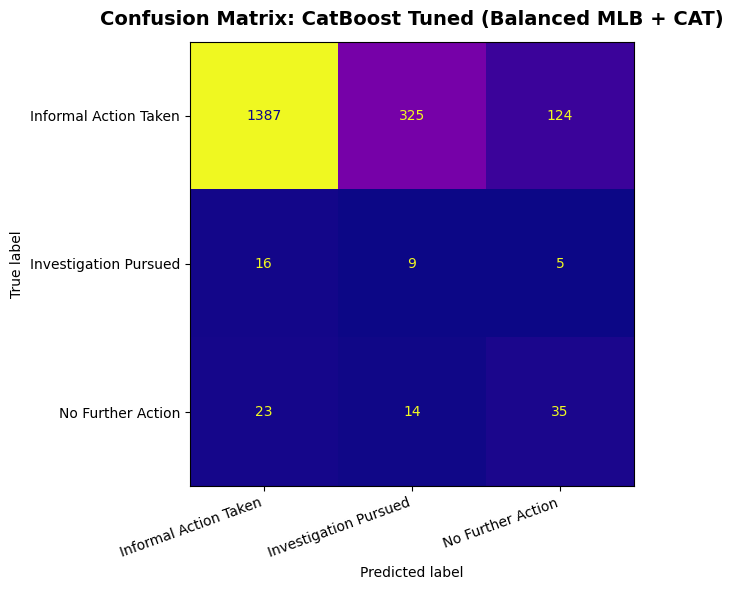

Confusion Matrix table:

                       Informal Action Taken  Investigation Pursued  \
Informal Action Taken                   1387                    325   
Investigation Pursued                     16                      9   
No Further Action                         23                     14   

                       No Further Action  
Informal Action Taken                124  
Investigation Pursued                  5  
No Further Action                     35  

Final CatBoost model, Best iteration found: 66


In [122]:
final_tuned_model, final_tuned_results = fit_catboost_classifier(
    "CatBoost Tuned (Balanced MLB + CAT)",
    X_train_cat,
    y_train,
    X_test_cat,
    y_test,
    X_val_cat,
    y_val,
    cat_feature_indices=cat_feature_indices,
    class_weights="Balanced",
    hyperparameters= bw_grid_result["params"]
)

print(f"\nFinal CatBoost model, Best iteration found: {final_tuned_model.get_best_iteration()}")


Feature importance (grouped by original feature):
original_feature
incident_type                47.812548
no_data_subjects_affected    14.659348
incident_category            12.755060
time_taken_to_report         10.477454
data_subject_type             7.370736
data_type                     6.924853

Top 15 raw features (including individual MLB sub-columns):
                                feature  importance          original_feature
                          incident_type   47.812548             incident_type
              no_data_subjects_affected   14.659348 no_data_subjects_affected
                      incident_category   12.755060         incident_category
                   time_taken_to_report   10.477454      time_taken_to_report
                data_type__ Health data    2.957798                 data_type
           data_subject_type__ Patients    2.169441         data_subject_type
            data_subject_type__Children    1.677667         data_subject_type
              

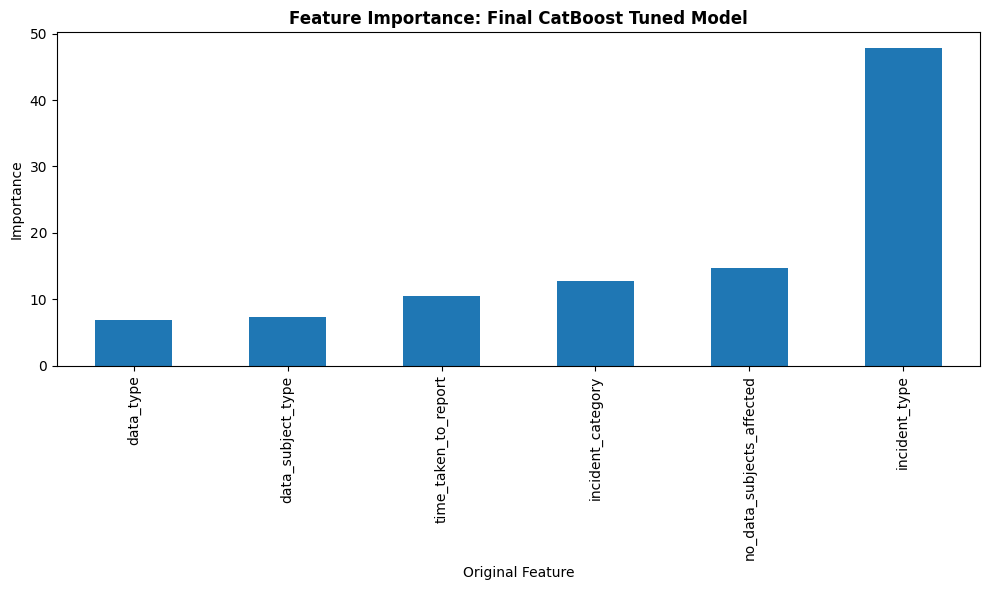

,feature,importance,original_feature
0,incident_category,12.755060,incident_category
1,incident_type,47.812548,incident_type
2,no_data_subjects_affected,14.659348,no_data_subjects_affected
3,time_taken_to_report,10.477454,time_taken_to_report
4,data_subject_type__ Customers or prospective c...,0.000000,data_subject_type
5,data_subject_type__ Employees,0.186987,data_subject_type
6,data_subject_type__ Patients,2.169441,data_subject_type
7,data_subject_type__ Students,0.000000,data_subject_type
8,data_subject_type__ Subscribers,0.000000,data_subject_type
9,data_subject_type__ Users,0.140459,data_subject_type


In [133]:
importances = final_tuned_model.get_feature_importance()
importance_df = pd.DataFrame({
    "feature": X_train_cat.columns,
    "importance": importances,
})
importance_df["original_feature"] = importance_df["feature"].apply(
    lambda c: get_original_feature(c, CATEGORICAL_COLS)
)
grouped = importance_df.groupby("original_feature")["importance"].sum().sort_values(ascending=False)

print("Feature importance (grouped by original feature):")
print(grouped.to_string())

print("\nTop 15 raw features (including individual MLB sub-columns):")
print(importance_df.sort_values("importance", ascending=False).head(15).to_string(index=False))

plot_feature_importance(
    importances,
    list(X_train_cat.columns),
    title="Feature Importance: Final CatBoost Tuned Model",
    categorical_cols=CATEGORICAL_COLS,
    group_by_original_feature=True,
)


Combined feature importance (built-in + permutation, grouped by original feature):
                           built_in  permutation
original_feature                                
incident_type                 47.81        11.49
no_data_subjects_affected     14.66         8.33
incident_category             12.76        77.59
time_taken_to_report          10.48        -0.94
data_subject_type              7.37         0.44
data_type                      6.92         3.10


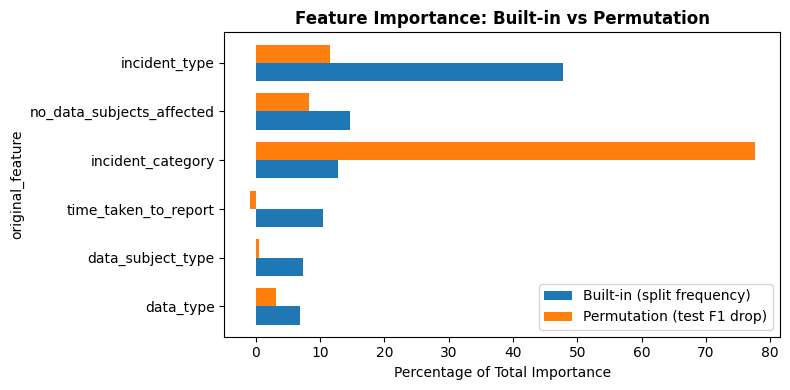


Raw permutation importance (per encoded column, top 15):
	incident_category             , Mean drop: +0.0621, Std: 0.0065
	incident_type                 , Mean drop: +0.0092, Std: 0.0052
	no_data_subjects_affected     , Mean drop: +0.0067, Std: 0.0028
	data_subject_type__Unknown    , Mean drop: +0.0016, Std: 0.0008
	data_type__ Health data       , Mean drop: +0.0006, Std: 0.0018
	data_type__Basic personal identifiers, Mean drop: +0.0003, Std: 0.0009
	data_subject_type__Employees  , Mean drop: +0.0003, Std: 0.0011
	data_subject_type__Customers or prospective customers, Mean drop: +0.0003, Std: 0.0006
	data_type__ Religious or philosophical beliefs, Mean drop: +0.0003, Std: 0.0008
	data_type__ Sex life data     , Mean drop: +0.0003, Std: 0.0008
	data_type__ Sexual orientation data, Mean drop: +0.0003, Std: 0.0008
	data_type__Unknown            , Mean drop: +0.0002, Std: 0.0005
	data_type__ Criminal convictions or offences, Mean drop: +0.0002, Std: 0.0008
	data_type__ Data revealing raci

In [ ]:
permutation_results = permutation_importance(
    final_tuned_model,
    X_test_cat,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=1,
    scoring="f1_macro"
)

permutation_importance_df = pd.DataFrame({
    "feature": X_train_cat.columns,
    "importance_mean": permutation_results["importances_mean"],
    "importance_std": permutation_results["importances_std"]
})
permutation_importance_df["original_feature"] = permutation_importance_df["feature"].apply(
    lambda c: get_original_feature(c, CATEGORICAL_COLS)
)
permutation_grouped = permutation_importance_df.groupby("original_feature")["importance_mean"].sum().sort_values(ascending=False)

combined_importance = pd.DataFrame({
    "built_in": grouped,
    "permutation": permutation_grouped
}).sort_values("built_in", ascending=False)

combined_importance_percent = combined_importance.div(combined_importance.sum()).mul(100).round(2)
print("\nCombined feature importance (built-in + permutation, grouped by original feature):")
print(combined_importance_percent.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
combined_importance_percent.iloc[::-1].plot(kind="barh", ax=ax, width=0.75)
ax.set_title("Feature Importance: Built-in vs Permutation", fontweight="bold")
ax.set_xlabel("Percentage of Total Importance")
ax.legend(["Built-in (split frequency)", "Permutation (test F1 drop)"])
plt.tight_layout()
plt.show()

print(f"\nRaw permutation importance (per encoded column, top 15):")
top_perm = permutation_importance_df.sort_values("importance_mean", ascending=False).head(15)
for _, row in top_perm.iterrows():
    print(f"\t{row['feature']:30s}, Mean drop: {row['importance_mean']:+.4f}, Std: {row['importance_std']:.4f}")


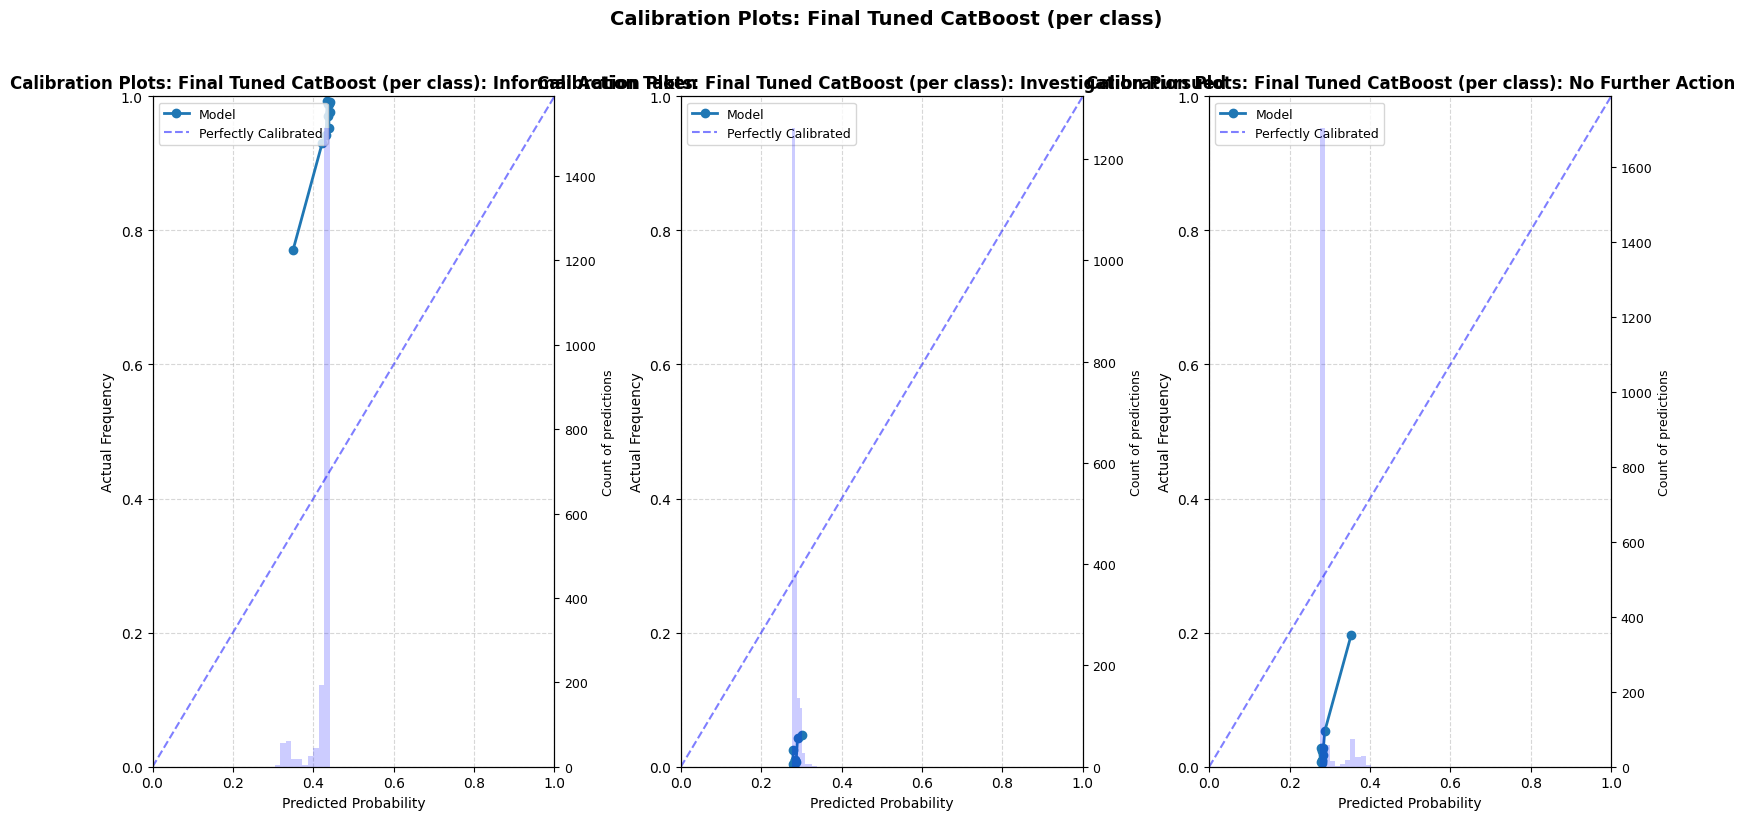

Brier score per class:
	Informal Action Taken    : 0.3181
	Investigation Pursued    : 0.0876
	No Further Action        : 0.0970


In [143]:
y_proba = final_tuned_model.predict_proba(X_test_cat)
proba_class_order = list(final_tuned_model.classes_)
proba_aligned = np.column_stack([y_proba[:, proba_class_order.index(c)] for c in CLASS_LABELS])

plot_calibration_curve(
    y_test, proba_aligned, CLASS_LABELS,
    title="Calibration Plots: Final Tuned CatBoost (per class)",
)

# Quantitative calibration summary, Brier score per class
print("Brier score per class:")
for i, class_name in enumerate(CLASS_LABELS):
    y_true_bin = (y_test.values == class_name).astype(int)
    brier = brier_score_loss(y_true_bin, proba_aligned[:, i])
    print(f"\t{class_name:25s}: {brier:.4f}")

In [ ]:
artifacts_path = Path(ARTIFACTS_PATH)
artifacts_path.mkdir(parents=True, exist_ok=True)

final_model_tuned.save_model(str(artifacts_path / "catboost_final.cbm"))
save_encoders(mlb_encoders, ohe_encoder, ARTIFACTS_DIR)

# Save the categorical feature indices and the full column ordering so the dashboard can rebuild a feature matrix with the correct shape.
import json
feature_metadata = {
    "feature_columns": list(X_train_cat.columns),
    "cat_feature_indices": cat_feature_indices,
    "categorical_cols": CATEGORICAL_COLS,
    "multilabel_cols": MULTILABEL_COLS,
    "class_labels": CLASS_LABELS
}

with open(artifacts_path / "feature_metadata.json", "w") as f:
    json.dump(feature_metadata, f, indent=2)

# Save a JSON of allowed values for each categorical input so the dashboard can populate dropdowns directly from this.
allowed_values = {}
for col in CATEGORICAL_COLS:
    allowed_values[col] = sorted(df_modelling[col].dropna().unique().tolist())
for col, mlb in mlb_encoders.items():
    allowed_values[col] = list(mlb.classes_)
with open(artifacts_path / "allowed_values.json", "w") as f:
    json.dump(allowed_values, f, indent=2)

print(f"Saved final model and encoders to {artifacts_path}/")
for path in sorted(artifacts_path.iterdir()):
    print(f"{path.name}")

Evaluating CatBoost Tuned (No Weights MLB + CAT)


Classification Report:
                       precision    recall  f1-score   support

Informal Action Taken       0.96      0.94      0.95      1836
Investigation Pursued       0.00      0.00      0.00        30
    No Further Action       0.22      0.42      0.29        72

             accuracy                           0.91      1938
            macro avg       0.39      0.45      0.41      1938
         weighted avg       0.92      0.91      0.91      1938

Accuracy: 0.9107
Macro F1 Score: 0.4138
Macro Precision: 0.3943
Macro Recall: 0.4539
Macro ROC AUC: 0.7346
Macro PR AUC: 0.3934
Log Loss: 0.8659

Per-Class F1 Scores:
	Informal Action Taken: F1 Score: 0.9543, ROC AUC: 0.7602
	Investigation Pursued: F1 Score: 0.0000, ROC AUC: 0.6685
	No Further Action: F1 Score: 0.2871, ROC AUC: 0.7749


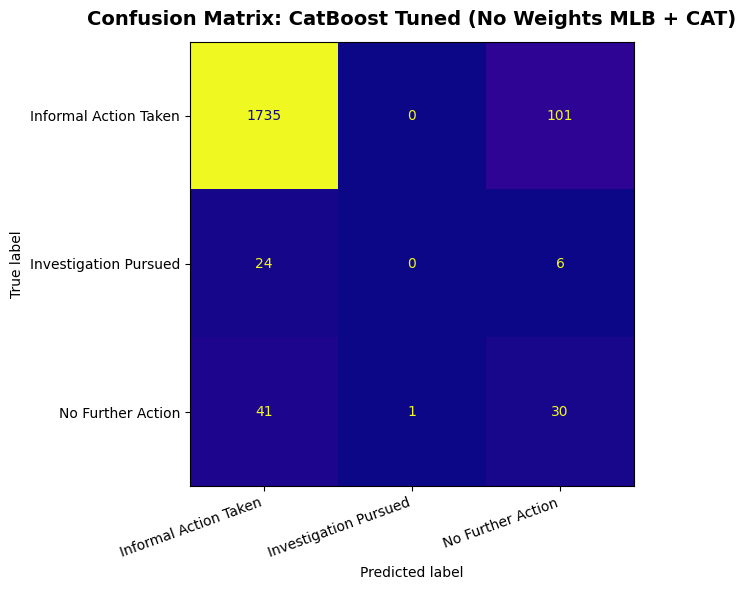

Confusion Matrix table:

                       Informal Action Taken  Investigation Pursued  \
Informal Action Taken                   1735                      0   
Investigation Pursued                     24                      0   
No Further Action                         41                      1   

                       No Further Action  
Informal Action Taken                101  
Investigation Pursued                  6  
No Further Action                     30  

Final CatBoost model, Best iteration found: 1


In [ ]:
# CHECKING WITH NO WEIGHTS
final_tuned_model, final_tuned_results = fit_catboost_classifier(
    "CatBoost Tuned (No Weights MLB + CAT)",
    X_train_cat,
    y_train,
    X_test_cat,
    y_test,
    X_val_cat,
    y_val,
    cat_feature_indices=cat_feature_indices,
    class_weights=None,
    hyperparameters= nw_grid_result["params"]
)

print(f"\nFinal CatBoost model, Best iteration found: {final_tuned_model.get_best_iteration()}")

Feature importance (grouped by original feature):
original_feature
incident_category            76.128367
data_type                     6.749588
data_subject_type             6.471954
no_data_subjects_affected     6.387246
time_taken_to_report          4.262844
incident_type                 0.000000

Top 15 raw features (including individual MLB sub-columns):
                                    feature  importance          original_feature
                          incident_category   76.128367         incident_category
                  no_data_subjects_affected    6.387246 no_data_subjects_affected
                       time_taken_to_report    4.262844      time_taken_to_report
      data_subject_type__ Vulnerable adults    3.437354         data_subject_type
                data_subject_type__Patients    2.401765         data_subject_type
                     data_type__Health data    2.375141                 data_type
                    data_type__ Health data    1.407325         

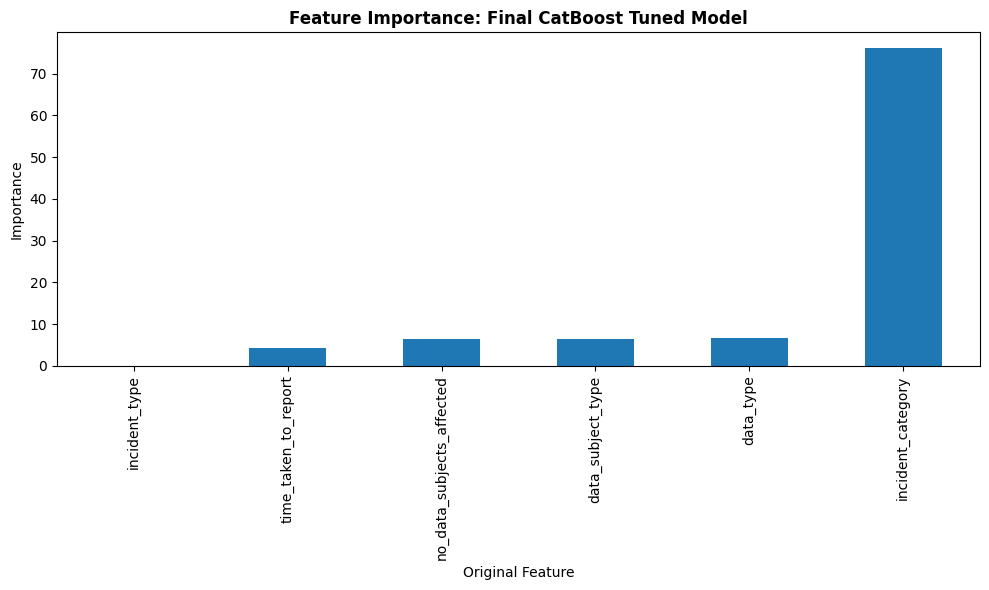

,feature,importance,original_feature
0,incident_category,76.128367,incident_category
1,incident_type,0.000000,incident_type
2,no_data_subjects_affected,6.387246,no_data_subjects_affected
3,time_taken_to_report,4.262844,time_taken_to_report
4,data_subject_type__ Customers or prospective c...,0.000000,data_subject_type
5,data_subject_type__ Employees,0.000000,data_subject_type
6,data_subject_type__ Patients,0.000000,data_subject_type
7,data_subject_type__ Students,0.000000,data_subject_type
8,data_subject_type__ Subscribers,0.237829,data_subject_type
9,data_subject_type__ Users,0.395007,data_subject_type


In [139]:
importances = final_tuned_model.get_feature_importance()
importance_df = pd.DataFrame({
    "feature": X_train_cat.columns,
    "importance": importances,
})
importance_df["original_feature"] = importance_df["feature"].apply(
    lambda c: get_original_feature(c, CATEGORICAL_COLS)
)
grouped = importance_df.groupby("original_feature")["importance"].sum().sort_values(ascending=False)

print("Feature importance (grouped by original feature):")
print(grouped.to_string())

print("\nTop 15 raw features (including individual MLB sub-columns):")
print(importance_df.sort_values("importance", ascending=False).head(15).to_string(index=False))

plot_feature_importance(
    importances,
    list(X_train_cat.columns),
    title="Feature Importance: Final CatBoost Tuned Model",
    categorical_cols=CATEGORICAL_COLS,
    group_by_original_feature=True,
)


Combined feature importance (built-in + permutation, grouped by original feature):
                           built_in  permutation
original_feature                                
incident_category             76.13       108.98
data_type                      6.75        -0.54
data_subject_type              6.47        -7.22
no_data_subjects_affected      6.39         5.66
time_taken_to_report           4.26        -6.89
incident_type                  0.00         0.00


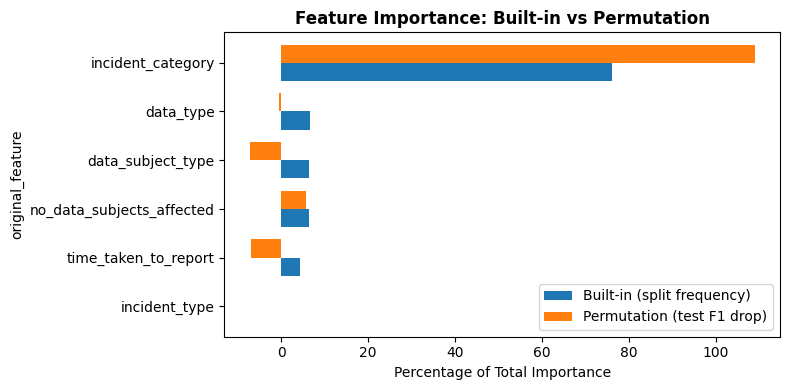


Raw permutation importance (per encoded column, top 15):
	incident_category             , Mean drop: +0.0855, Std: 0.0053
	no_data_subjects_affected     , Mean drop: +0.0044, Std: 0.0050
	data_type__ Health data       , Mean drop: +0.0010, Std: 0.0040
	data_type__ Genetic or biometric data, Mean drop: +0.0004, Std: 0.0002
	data_type__Identification data, Mean drop: +0.0003, Std: 0.0008
	data_type__Criminal convictions or offences, Mean drop: +0.0001, Std: 0.0002
	data_subject_type__Employees  , Mean drop: +0.0000, Std: 0.0000
	data_subject_type__ Students  , Mean drop: +0.0000, Std: 0.0000
	data_subject_type__Customers or prospective customers, Mean drop: +0.0000, Std: 0.0000
	data_subject_type__Children   , Mean drop: +0.0000, Std: 0.0000
	incident_type                 , Mean drop: +0.0000, Std: 0.0000
	data_subject_type__ Customers or prospective customers, Mean drop: +0.0000, Std: 0.0000
	data_subject_type__ Employees , Mean drop: +0.0000, Std: 0.0000
	data_subject_type__ Patients 

In [140]:
permutation_results = permutation_importance(
    final_tuned_model,
    X_test_cat,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=1,
    scoring="f1_macro"
)

permutation_importance_df = pd.DataFrame({
    "feature": X_train_cat.columns,
    "importance_mean": permutation_results["importances_mean"],
    "importance_std": permutation_results["importances_std"]
})
permutation_importance_df["original_feature"] = permutation_importance_df["feature"].apply(
    lambda c: get_original_feature(c, CATEGORICAL_COLS)
)
permutation_grouped = permutation_importance_df.groupby("original_feature")["importance_mean"].sum().sort_values(ascending=False)

combined_importance = pd.DataFrame({
    "built_in": grouped,
    "permutation": permutation_grouped
}).sort_values("built_in", ascending=False)

combined_importance_percent = combined_importance.div(combined_importance.sum()).mul(100).round(2)
print("\nCombined feature importance (built-in + permutation, grouped by original feature):")
print(combined_importance_percent.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
combined_importance_percent.iloc[::-1].plot(kind="barh", ax=ax, width=0.75)
ax.set_title("Feature Importance: Built-in vs Permutation", fontweight="bold")
ax.set_xlabel("Percentage of Total Importance")
ax.legend(["Built-in (split frequency)", "Permutation (test F1 drop)"])
plt.tight_layout()
plt.show()

print(f"\nRaw permutation importance (per encoded column, top 15):")
top_perm = permutation_importance_df.sort_values("importance_mean", ascending=False).head(15)
for _, row in top_perm.iterrows():
    print(f"\t{row['feature']:30s}, Mean drop: {row['importance_mean']:+.4f}, Std: {row['importance_std']:.4f}")
